In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

In [278]:
df = pd.read_excel('../Data/Data_finance_lab3.xlsx', sheet_name='data_final')
y = df['RESULT_YES/NO']

In [279]:
df.head(5)

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


In [280]:
df.columns

Index(['APP_ID', 'DISBURSALDATE', 'REPORT_DATE', 'TERM_TMP', 'PRODUCT_NAME',
       'LOANAMOUNT_NOT_INSURANCE', 'INSURANCE_FEE', 'LA', 'EFF_RATE', 'TERM',
       'COUNT_TERM_RECEIPT', 'flag term', 'SUM_RECEIPT_AMT', 'Unnamed: 13',
       'flag loan amt', 'flag final', 'RESULT_YES/NO', 'EMI', 'GENDER', 'AGE',
       'Number of Children', 'PERSONAL_INCOME', 'ADDITIONAL_INCOME',
       'PERSONAL_EXPENSE', 'FAMILY_INCOME', 'FAMILY_EXPENSE', 'MARITAL_STATUS',
       'EDUCATION', 'City', 'ADDRESS_CURRENT_CITY', 'PROVINCE_CURRENT'],
      dtype='object')

# Missing Values Handling

In [281]:
df['flag final'].fillna(-1, inplace=True)
df['flag loan amt'].fillna(-1, inplace=True)
df['flag term'].fillna(-1, inplace=True)
df['SUM_RECEIPT_AMT'].fillna(0, inplace=True)
df['COUNT_TERM_RECEIPT'].fillna(0, inplace=True)
df['Number of Children'].fillna(0, inplace=True)
df.drop(['Unnamed: 13'], inplace=True, axis=1)

In [282]:
df.isnull().sum()

APP_ID                      0
DISBURSALDATE               0
REPORT_DATE                 0
TERM_TMP                    0
PRODUCT_NAME                0
LOANAMOUNT_NOT_INSURANCE    0
INSURANCE_FEE               0
LA                          0
EFF_RATE                    0
TERM                        0
COUNT_TERM_RECEIPT          0
flag term                   0
SUM_RECEIPT_AMT             0
flag loan amt               0
flag final                  0
RESULT_YES/NO               0
EMI                         0
GENDER                      0
AGE                         0
Number of Children          0
PERSONAL_INCOME             0
ADDITIONAL_INCOME           0
PERSONAL_EXPENSE            0
FAMILY_INCOME               0
FAMILY_EXPENSE              0
MARITAL_STATUS              0
EDUCATION                   0
City                        0
ADDRESS_CURRENT_CITY        0
PROVINCE_CURRENT            0
dtype: int64

# Feature Selection

In [283]:
features = ['LA', 'TERM', 'LOANAMOUNT_NOT_INSURANCE', 'INSURANCE_FEE', 'SUM_RECEIPT_AMT', 'EMI', 'COUNT_TERM_RECEIPT', 'PERSONAL_EXPENSE', 'PERSONAL_INCOME']
featured_df = df[features]

In [284]:
featured_df.head()

,LA,TERM,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,SUM_RECEIPT_AMT,EMI,COUNT_TERM_RECEIPT,PERSONAL_EXPENSE,PERSONAL_INCOME
0,18990000,24,18000000,990000,14701000.0,1213820,12.0,9600000,9000000
1,10550000,12,10000000,550000,13465000.0,1105184,13.0,7200000,5500000
2,26375000,24,25000000,1375000,19003625.0,1715125,11.0,12000000,5182000
3,31650000,24,30000000,1650000,18741000.0,2014302,10.0,18000000,10000000
4,21100000,18,20000000,1100000,19673856.0,1627488,12.0,12000000,7000000


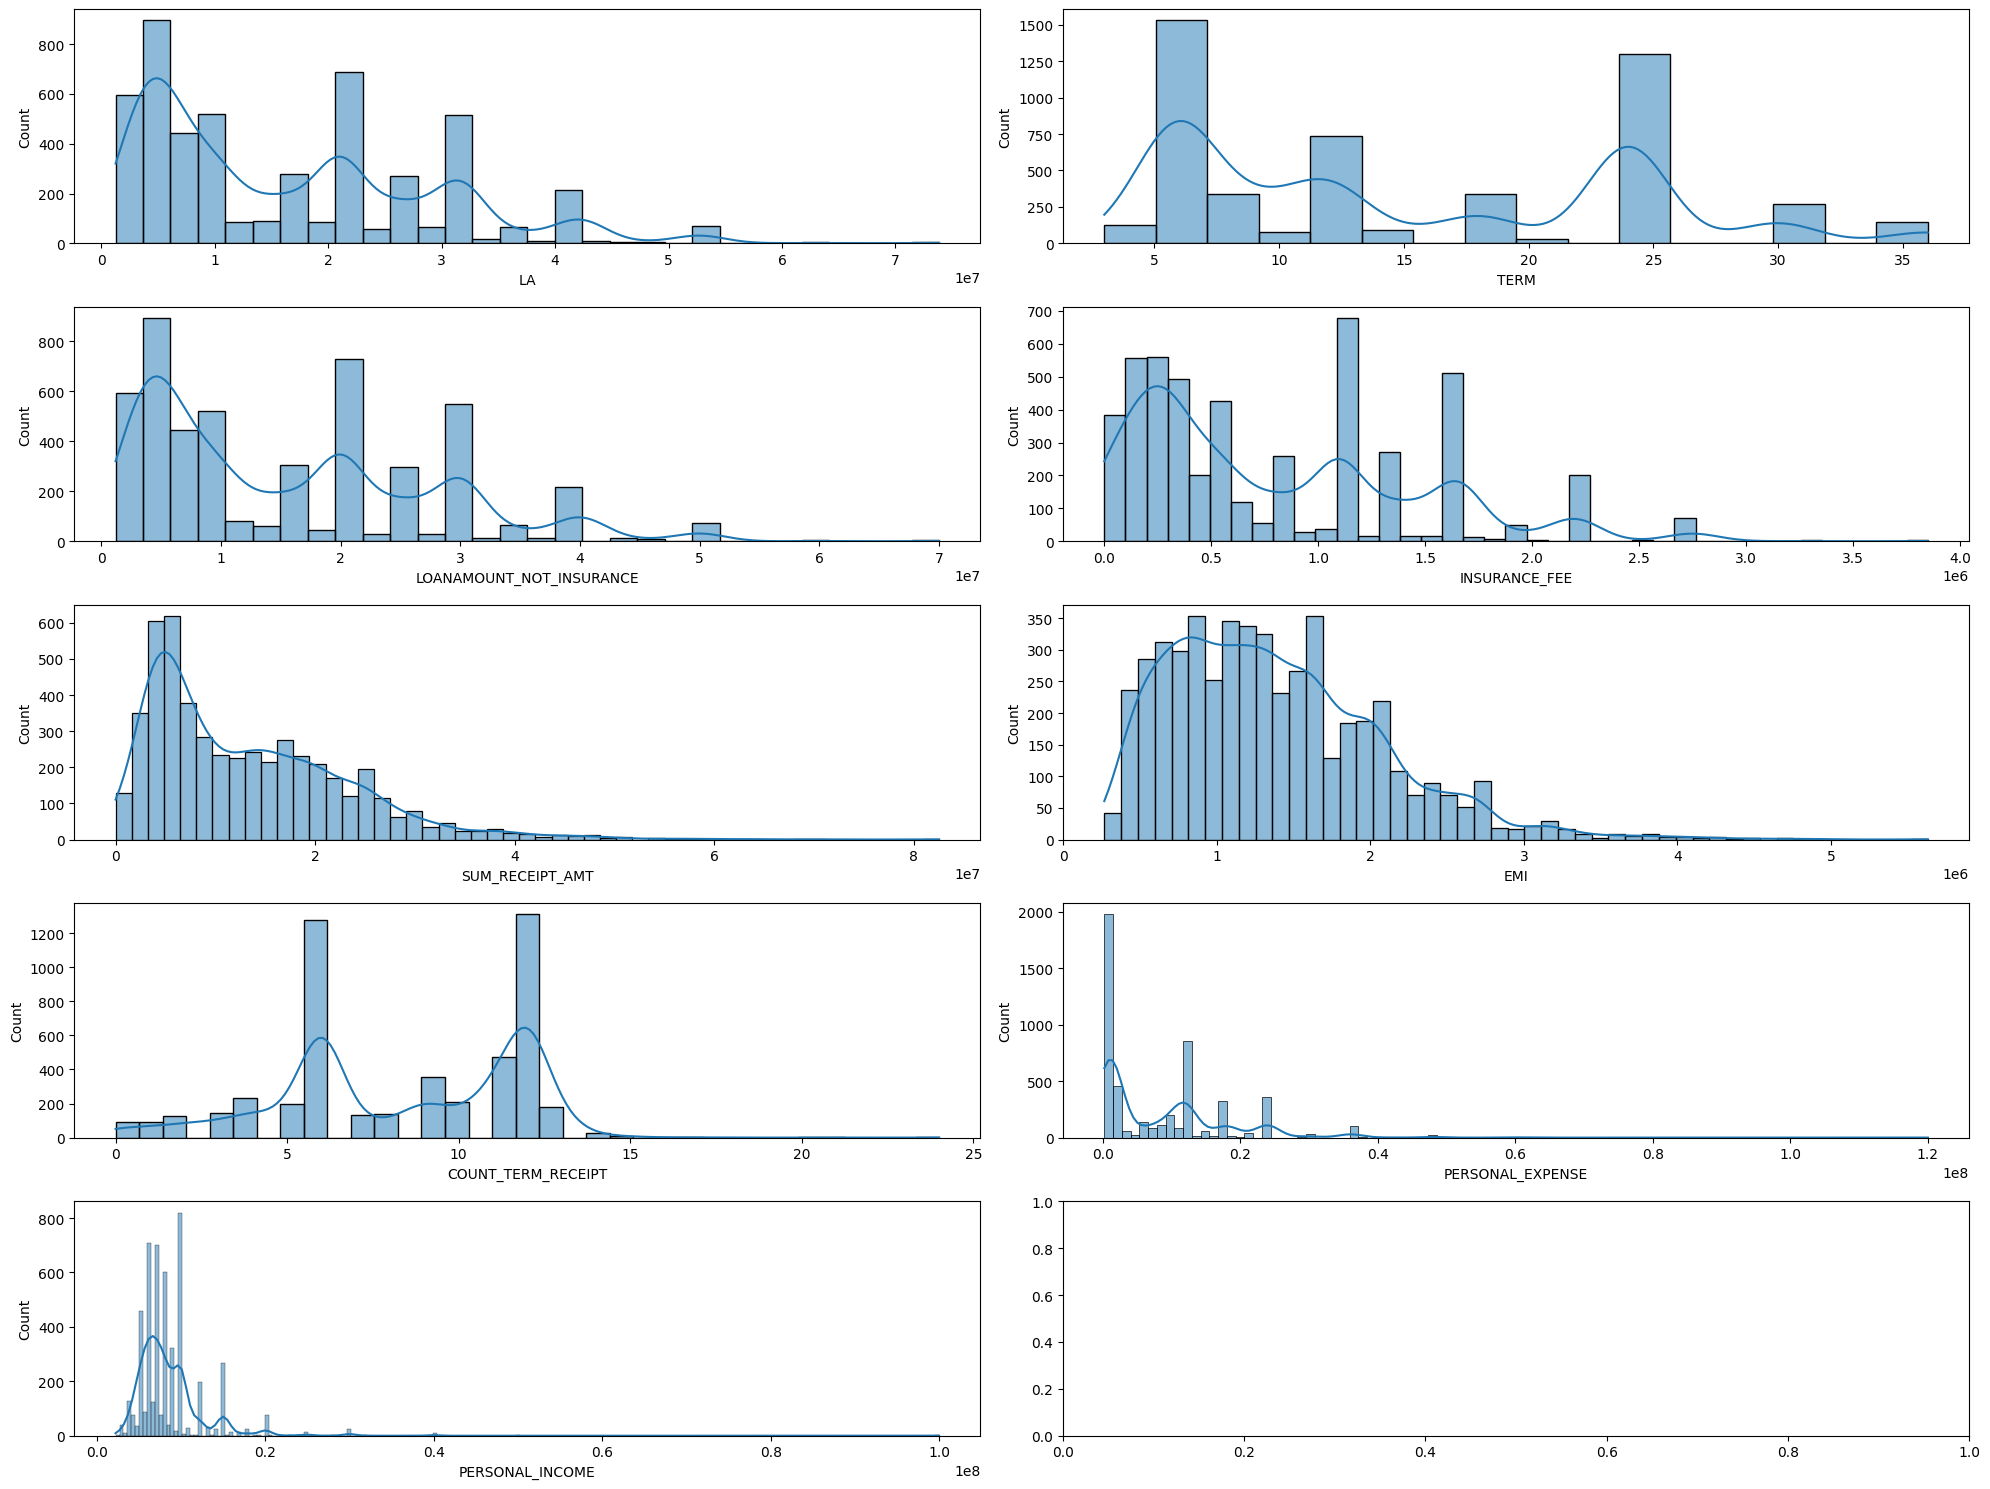

In [285]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 15))
axes = axes.flatten()
for i, num in enumerate(featured_df.columns):
    sns.histplot(data=featured_df, x=num, ax=axes[i], kde=True)
plt.tight_layout()
plt.show()

In [286]:
old_skew = featured_df.skew().sort_values(ascending=False)
old_skew

PERSONAL_INCOME             4.492390
PERSONAL_EXPENSE            2.137461
SUM_RECEIPT_AMT             1.252532
EMI                         0.970174
INSURANCE_FEE               0.912722
LA                          0.877167
LOANAMOUNT_NOT_INSURANCE    0.874218
TERM                        0.505103
COUNT_TERM_RECEIPT         -0.329077
dtype: float64

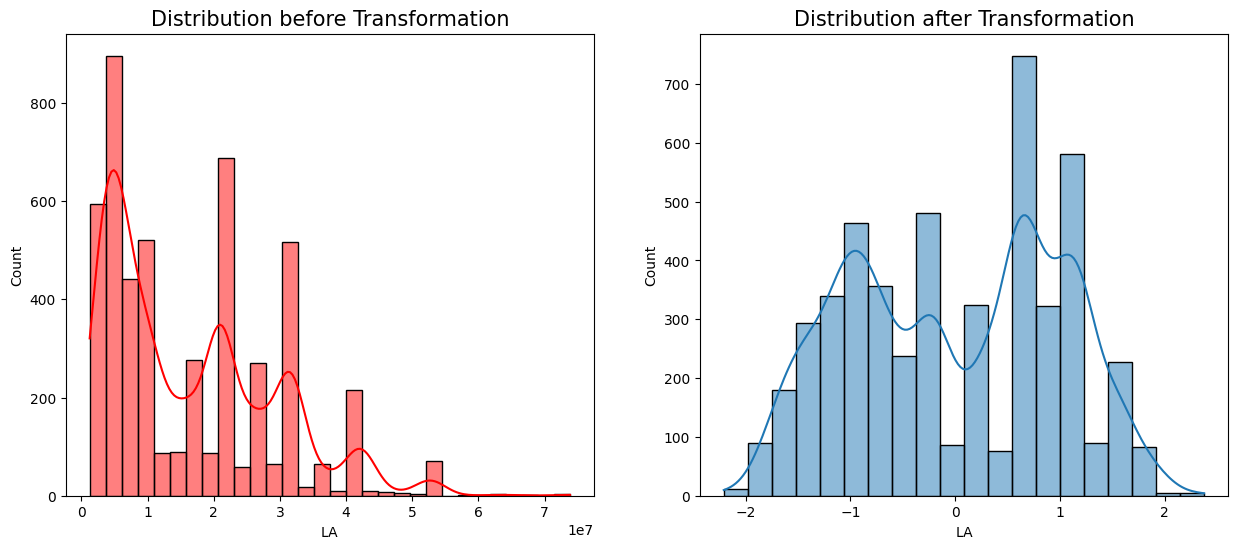

Skewness was 0.88 before & is -0.06 after Yeo-johnson transformation.


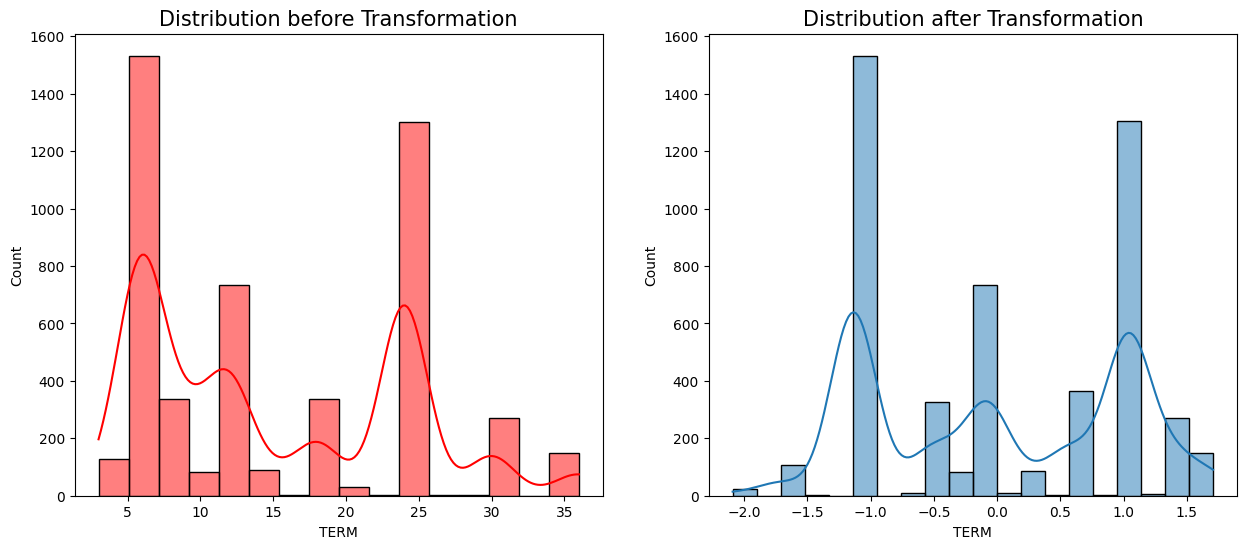

Skewness was 0.51 before & is 0.0 after Yeo-johnson transformation.


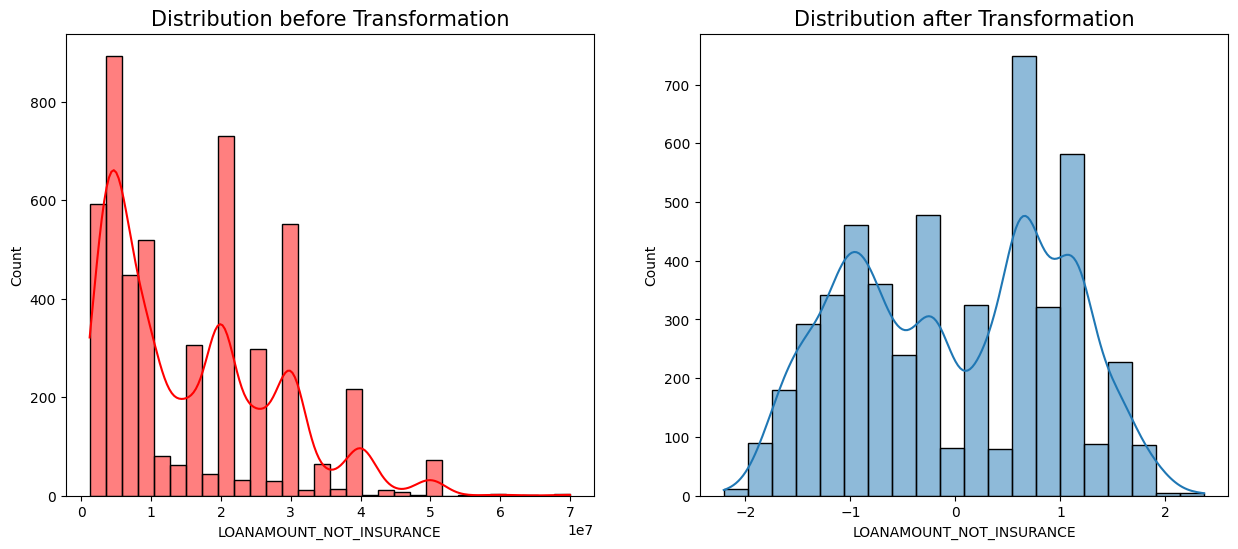

Skewness was 0.87 before & is -0.06 after Yeo-johnson transformation.


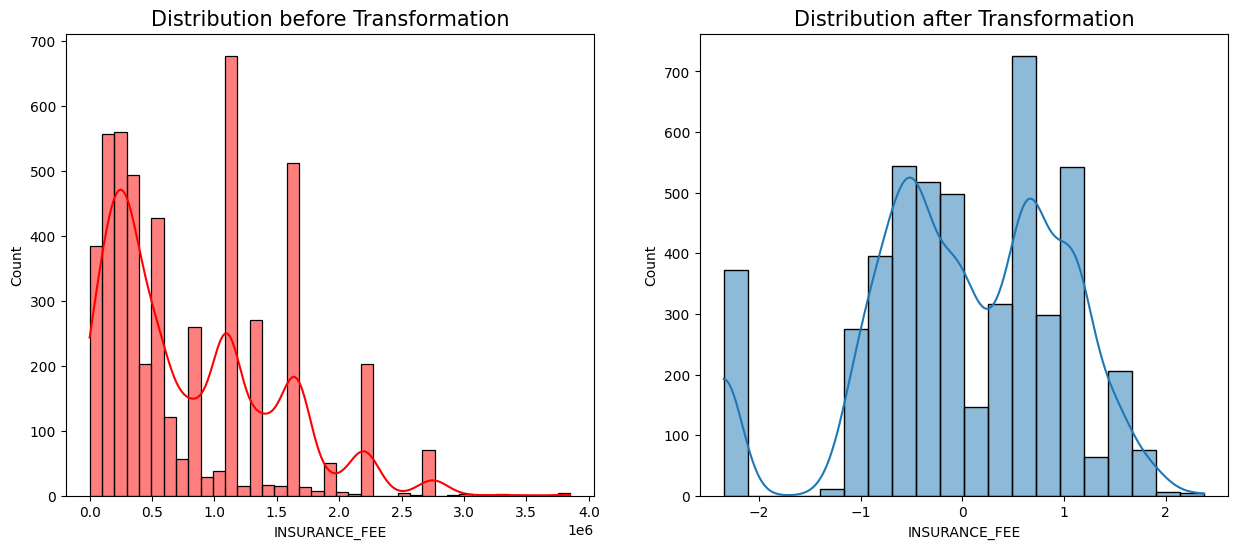

Skewness was 0.91 before & is -0.58 after Yeo-johnson transformation.


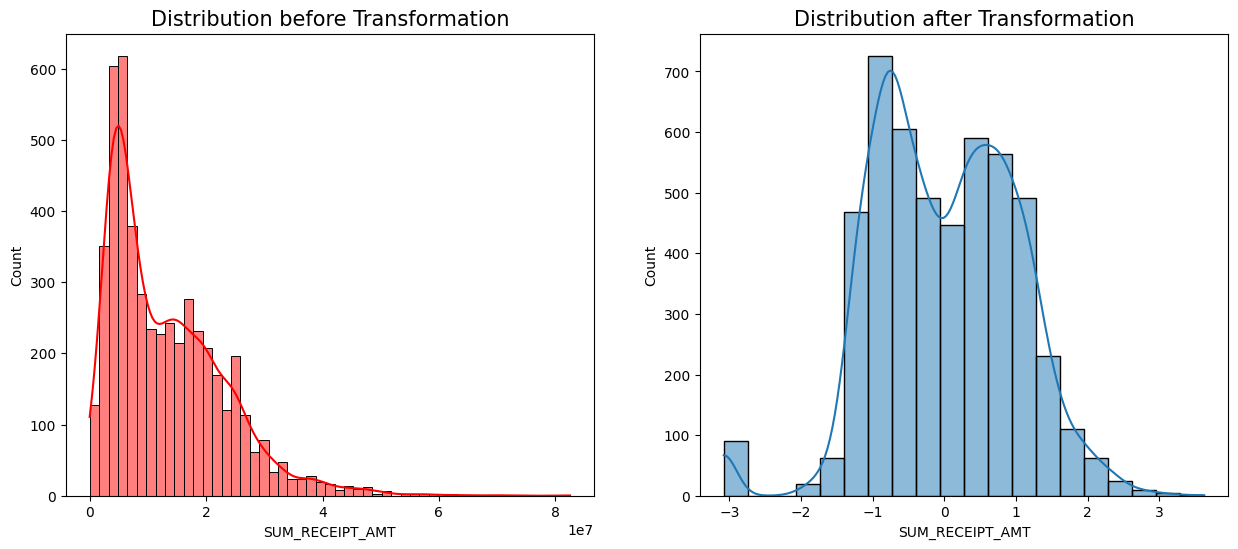

Skewness was 1.25 before & is -0.17 after Yeo-johnson transformation.


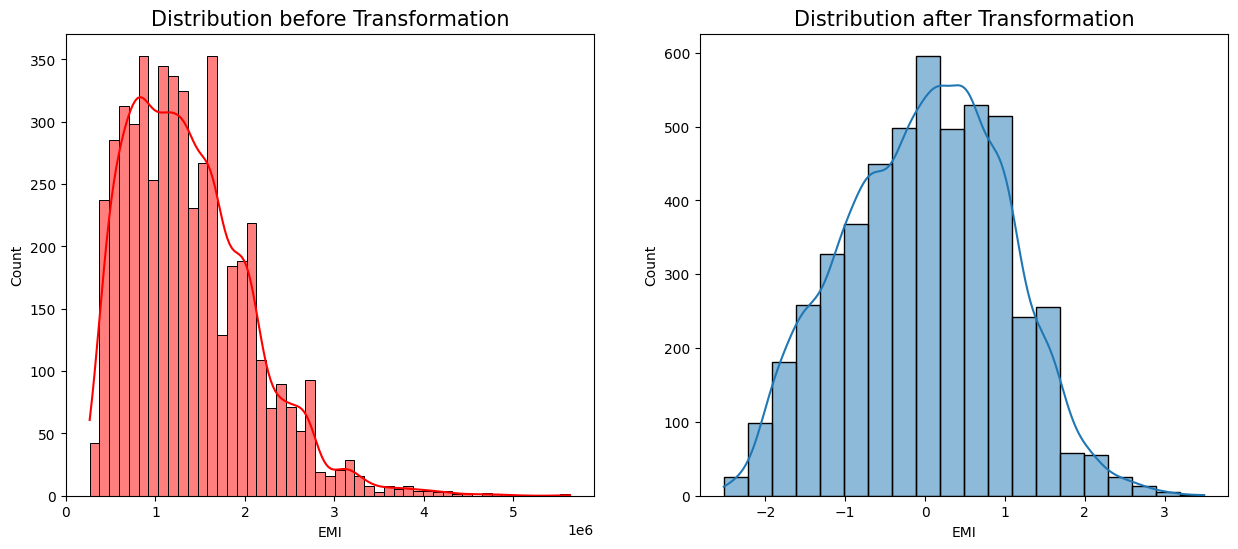

Skewness was 0.97 before & is -0.02 after Yeo-johnson transformation.


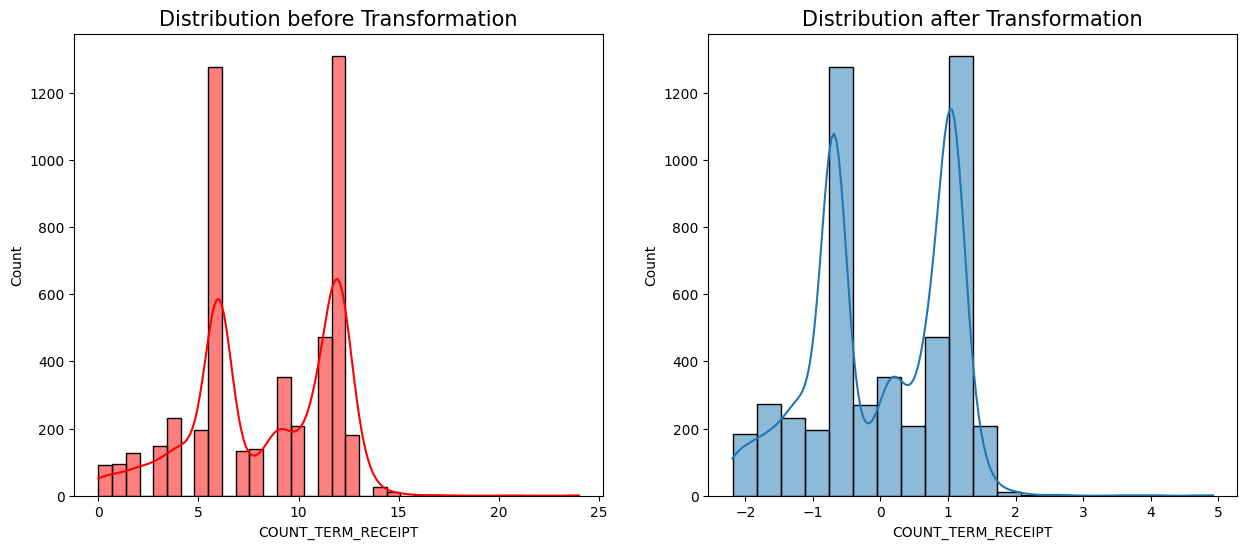

Skewness was -0.33 before & is -0.22 after Yeo-johnson transformation.


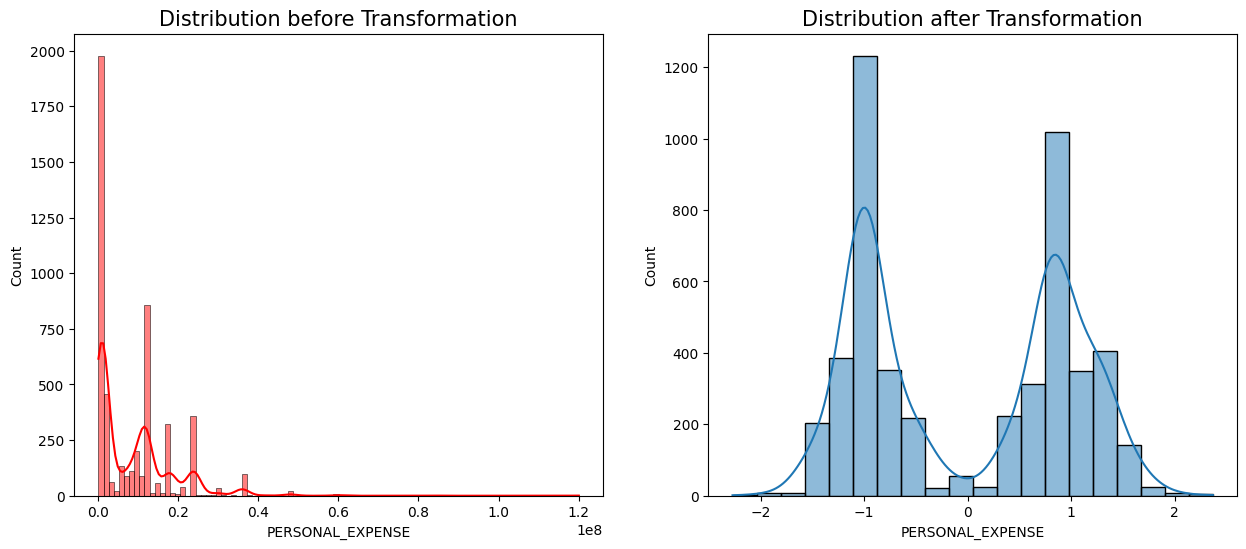

Skewness was 2.14 before & is 0.03 after Yeo-johnson transformation.


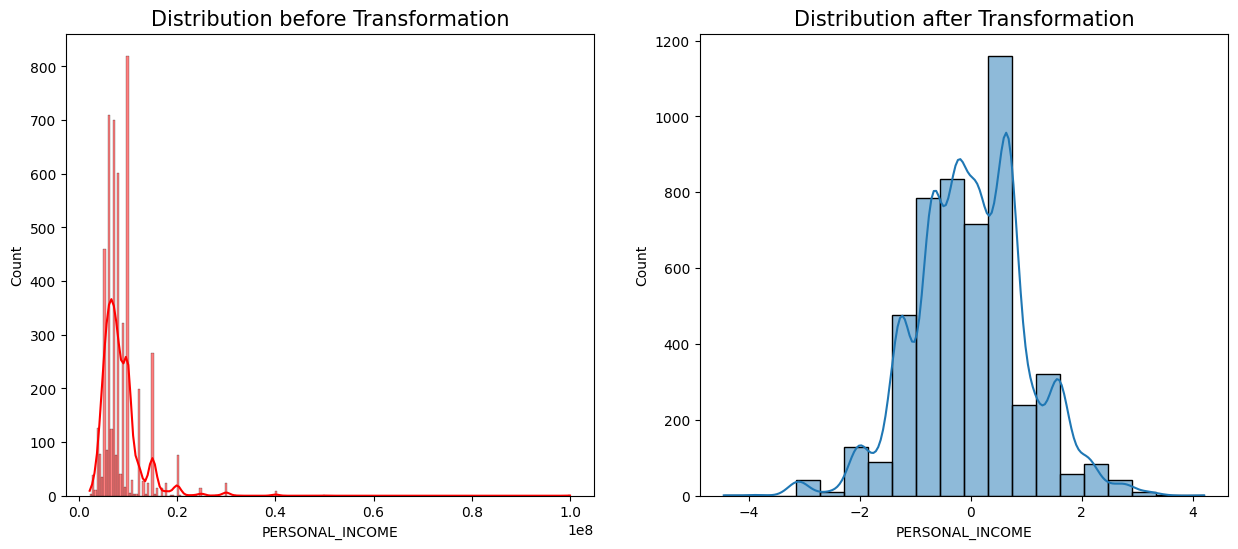

Skewness was 4.49 before & is -0.03 after Yeo-johnson transformation.


In [287]:
def yeojohntrans(feature):   # function to apply transformer and check the distribution with histogram and kdeplot 
    yeojohnTr = PowerTransformer(standardize=True)   # not using method attribute as yeo-johnson is the default

    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    plt.title("Distribution before Transformation", fontsize=15)
    sns.histplot(featured_df[feature], kde=True, color="red")
    plt.subplot(1,2,2)
    
    df_yeojohn = pd.DataFrame(yeojohnTr.fit_transform(featured_df[feature].values.reshape(-1,1)))
    plt.title("Distribution after Transformation", fontsize=15)
    sns.histplot(df_yeojohn,bins=20, kde=True , legend=False)
    plt.xlabel(feature)
    plt.show()
     
    print(f"Skewness was {round(old_skew[feature],2)} before & is {round(df_yeojohn.skew()[0],2)} after Yeo-johnson transformation.")
    
    return df_yeojohn


transformed_df = pd.DataFrame(featured_df)
for i in featured_df.columns:
    transformed_df[i] = yeojohntrans(i)

In [288]:
transformed_df.head()

,LA,TERM,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,SUM_RECEIPT_AMT,EMI,COUNT_TERM_RECEIPT,PERSONAL_EXPENSE,PERSONAL_INCOME
0,0.508110,1.038548,0.503397,0.531531,0.386539,-0.048222,1.063178,0.689453,0.423001
1,-0.184085,-0.077600,-0.187217,-0.024735,0.271946,-0.227072,1.368903,0.486273,-0.960066
2,0.924120,1.038548,0.918385,0.898179,0.744426,0.645299,0.761000,0.845298,-1.148027
3,1.164566,1.038548,1.158218,1.121343,0.724112,0.986962,0.462621,1.124608,0.682789
4,0.639175,0.570200,0.634145,0.644399,0.795492,0.536533,1.063178,0.845298,-0.246251


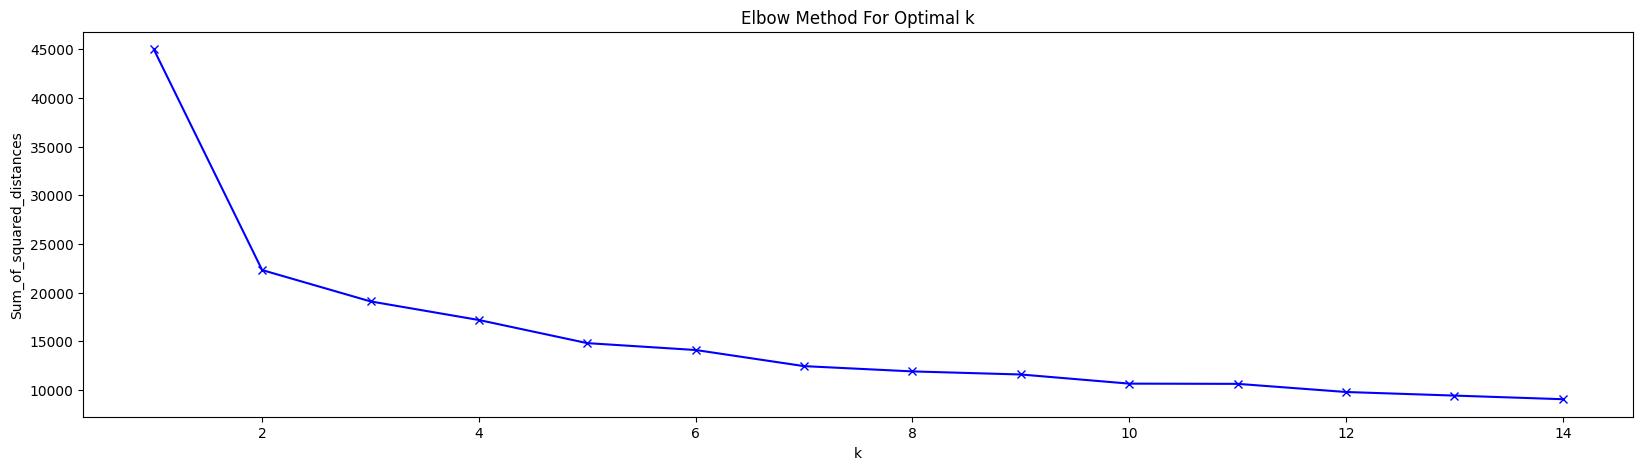

In [289]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(transformed_df)


Sum_of_squared_distances = []
K = range(1,15)
for k in K:
    km = KMeans(n_clusters=k)
    km = km.fit(cluster_scaled)
    Sum_of_squared_distances.append(km.inertia_)
plt.figure(figsize=(20,5))
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [290]:
model = KMeans(n_clusters=2)
model.fit(cluster_scaled)
kmeans_labels = model.labels_
kmeans_labels

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [291]:
#count
df['kmeans_labels'] = kmeans_labels
df['kmeans_labels'].value_counts()

kmeans_labels
0    2741
1    2259
Name: count, dtype: int64

K-Means


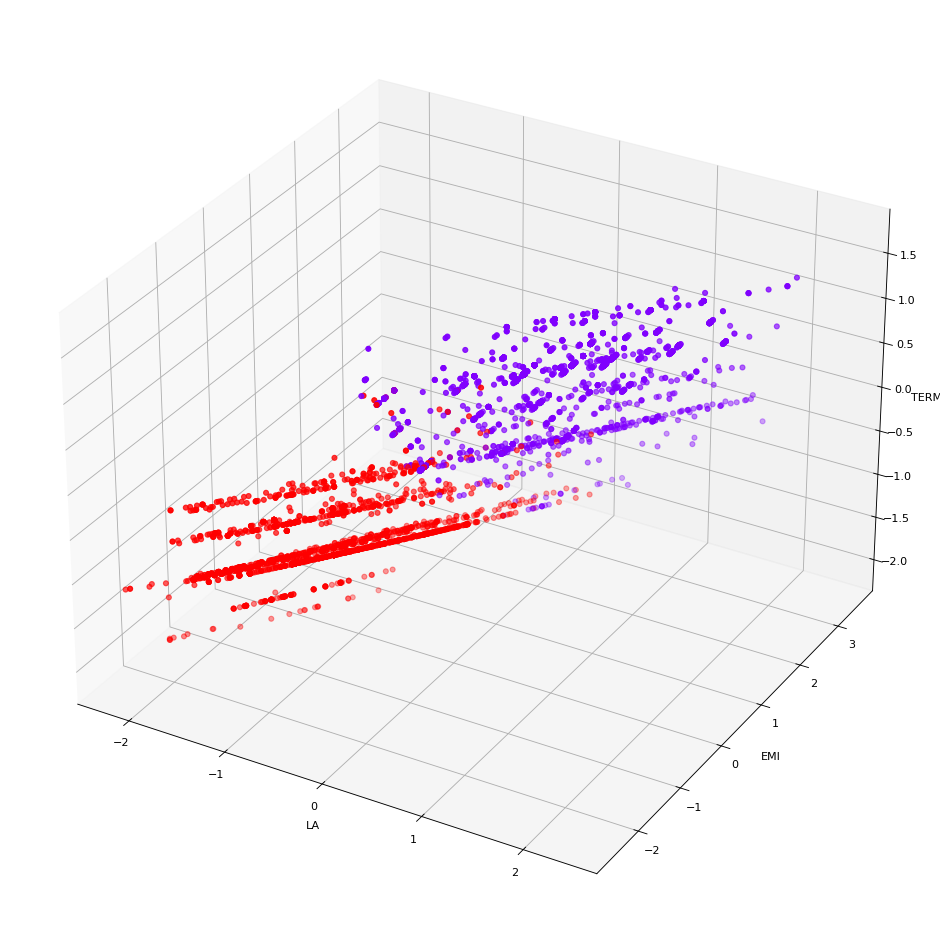

In [292]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(num=None, figsize=(20, 15), dpi=80, facecolor='w', edgecolor='k')

ax = plt.axes(projection="3d")

ax.scatter3D(transformed_df['LA'],transformed_df['EMI'],transformed_df['TERM'],c=kmeans_labels, cmap='rainbow')

xLabel = ax.set_xlabel('LA', linespacing=3.2)
yLabel = ax.set_ylabel('EMI', linespacing=3.1)
zLabel = ax.set_zlabel('TERM', linespacing=3.4)
print("K-Means")

In [293]:
df_clustered_kmeans = transformed_df.assign(Cluster=kmeans_labels)
grouped_kmeans = df_clustered_kmeans.groupby(['Cluster']).mean().round(1)
grouped_kmeans

,LA,TERM,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,SUM_RECEIPT_AMT,EMI,COUNT_TERM_RECEIPT,PERSONAL_EXPENSE,PERSONAL_INCOME
Cluster,,,,,,,,,
0,0.8,0.8,0.8,0.6,0.6,0.6,0.5,0.7,0.2
1,-1.0,-0.9,-1.0,-0.7,-0.7,-0.7,-0.6,-0.9,-0.3


In [294]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y, kmeans_labels)

0.6142

# Feature Engineering

### Repayment Rate

In [295]:
df['REPAYMENT_RATE'] = df['SUM_RECEIPT_AMT'] / df['LA']

### Remaining Term

In [296]:
df['REMAINING_TERM'] = df['TERM'] - df['COUNT_TERM_RECEIPT']

### Expense to Income Ratio

In [297]:
df['EXPENSE_INCOME_RATIO'] = (df['PERSONAL_EXPENSE'] + df['FAMILY_EXPENSE']) / (df['PERSONAL_INCOME'] + df['ADDITIONAL_INCOME'] + df['FAMILY_INCOME'])

### Income

In [298]:
df['INCOME'] = df['PERSONAL_INCOME'] + df['ADDITIONAL_INCOME'] + df['FAMILY_INCOME'] - df['PERSONAL_EXPENSE'] - df['FAMILY_EXPENSE']

### Age to Term Ratio

In [299]:
df['AGE_TERM_RATIO'] = df['AGE'] / df['TERM']

### Insurance to Loan Ratio

In [300]:
df['INSURANCE_LOAN_RATIO'] = df['INSURANCE_FEE'] / df['LOANAMOUNT_NOT_INSURANCE']

In [301]:
df.to_csv('../Data/Data_finance_lab3_featured.csv', index=False)